# 3D Print Failure Prediction Notebook
**Cornell Tech MakerLAB Project**

This notebook is for exploring the synthetic dataset, identifying useful features, documenting class imbalance, and handing a clean column list to Owner B.

**Deliverables:**
- `data/raw/feature_candidates.json` (cleaned column list for B)
- Completed notebook with all required plots

Run cells from top to bottom. Do not modify files in `data/raw/`.

## 0. Setup

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import json, os, warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'sans-serif',
})
sns.set_palette('muted')

DATA_DIR = '../data/raw'
TARGET = 'failure_predicted'

## 1. Load all three dataset sizes and compare

In [41]:
sizes = [100, 1000, 5000]
dfs = {}
for n in sizes:
    path = os.path.join(DATA_DIR, f'makerlab_dataset_{n}_rows.csv')
    dfs[n] = pd.read_csv(path)
    print(f'{n}-row dataset: {dfs[n].shape[0]} rows × {dfs[n].shape[1]} cols')

# Work with the 5000-row dataset for EDA
df = dfs[5000].copy()
print(f'\nWorking dataset shape: {df.shape}')

100-row dataset: 100 rows × 459 cols
1000-row dataset: 1000 rows × 459 cols
5000-row dataset: 5000 rows × 459 cols

Working dataset shape: (5000, 459)


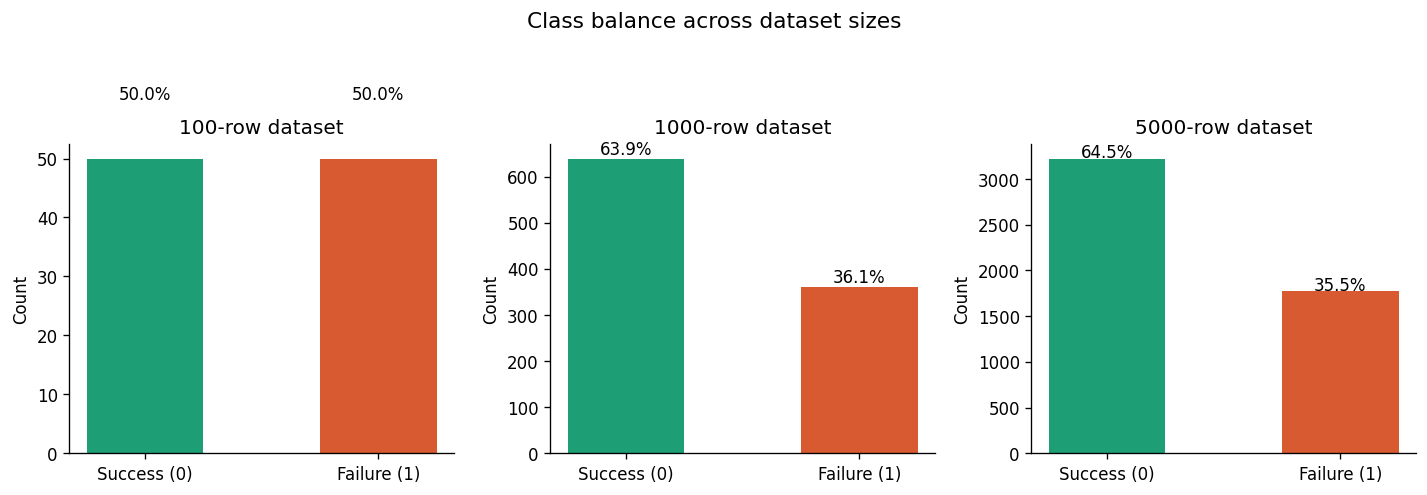


5000-row class balance:
failure_predicted
1    0.645
0    0.355
Name: proportion, dtype: float64


In [42]:
# Compare class balance across dataset sizes
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, n in zip(axes, sizes):
    counts = dfs[n][TARGET].value_counts()
    ax.bar(['Success (0)', 'Failure (1)'], counts.values,
           color=['#1D9E75', '#D85A30'], width=0.5)
    ax.set_title(f'{n}-row dataset')
    ax.set_ylabel('Count')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 10, f'{v/len(dfs[n]):.1%}', ha='center', fontsize=10)
plt.suptitle('Class balance across dataset sizes', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print('\n5000-row class balance:')
print(df[TARGET].value_counts(normalize=True).round(3))

## 2. Drop zero-variance columns

In [43]:
# Find columns with only one unique value
zero_var_cols = [c for c in df.columns if df[c].nunique() <= 1]
print(f'Zero-variance columns ({len(zero_var_cols)} total):')
for c in zero_var_cols[:20]:   # show first 20
    print(f'  {c}: {df[c].unique()[0] if len(df[c].unique()) > 0 else "empty"}')
if len(zero_var_cols) > 20:
    print(f'  ... and {len(zero_var_cols) - 20} more')

print(f'\nConfirmed zero-variance: printer_model = {df["printer_model"].unique()}')
print(f'Confirmed zero-variance: nozzle_type = {df["nozzle_type"].unique()}')

Zero-variance columns (409 total):
  accel_to_decel_enable: 0
  accel_to_decel_factor: 50%
  apply_scarf_seam_on_circles: 1
  apply_top_surface_compensation: 0
  auxiliary_fan: 1
  avoid_crossing_wall_includes_support: 0
  bed_exclude_area: 0x0,18x0,18x28,0x28
  bed_temperature_formula: by_first_filament
  best_object_pos: 0.5,0.5
  bottom_color_penetration_layers: 3
  bottom_shell_layers: 3
  bottom_shell_thickness: 0
  bottom_surface_pattern: monotonic
  bridge_angle: 0
  bridge_flow: 1
  bridge_no_support: 0
  brim_object_gap: 0.1
  brim_type: auto_brim
  change_filament_gcode: ;=X1 20250822=\nM620 S[next_extruder]A\nM204 S9000\nG1 Z{max_layer_z + 3.0} F1200\n\nG1 X70 F21000\nG1 Y245\nG1 Y265 F3000\nM400\nM106 P1 S0\nM106 P2 S0\n{if nozzle_temperature[previous_extruder] > 142 && next_extruder < 255}\nM104 S{nozzle_temperature[previous_extruder]}\n{endif}\n{if long_retractions_when_cut[previous_extruder]}\nM620.11 S1 I[previous_extruder] E-{retraction_distances_when_cut[previous_extr

In [44]:
# Drop zero-variance columns
df_clean = df.drop(columns=zero_var_cols)
print(f'Columns after dropping zero-variance: {df.shape[1]} → {df_clean.shape[1]}')

Columns after dropping zero-variance: 459 → 50


## 3. Null value audit

In [45]:
null_counts = df_clean.isnull().sum()
null_pct = (null_counts / len(df_clean) * 100).round(1)
null_summary = pd.DataFrame({'null_count': null_counts, 'null_pct': null_pct})
null_summary = null_summary[null_summary['null_count'] > 0].sort_values('null_pct', ascending=False)

print(f'Columns with nulls: {len(null_summary)}')
print(null_summary.to_string())

print('\nRecommended strategy:')
for col, row in null_summary.iterrows():
    dtype = df_clean[col].dtype
    strategy = 'median imputation' if np.issubdtype(dtype, np.number) else 'mode imputation'
    print(f'  {col} ({row["null_pct"]}% null) → {strategy}')

Columns with nulls: 0
Empty DataFrame
Columns: [null_count, null_pct]
Index: []

Recommended strategy:


## 4. Feature candidate selection

Narrow from hundreds of columns to the ~15–20 that are pre-print knowable and likely to carry signal.

In [46]:
# Candidate features — pre-print knowable, non-constant, sufficient variance
NUMERIC_CANDIDATES = [
    'nozzle_temperature',
    'nozzle_temperature_initial_layer',
    'layer_height',
    'initial_layer_print_height',
    'inner_wall_speed',
    'outer_wall_speed',
    'bridge_speed',
    'fan_max_speed',
    'sparse_infill_density',
    'bottom_shell_layers',
    'top_shell_layers',
    'wall_loops',
    'retraction_length',
    'retraction_speed',
    'enable_support',
]
CATEGORICAL_CANDIDATES = ['filament_type']
ALL_CANDIDATES = NUMERIC_CANDIDATES + CATEGORICAL_CANDIDATES

# Check they exist and report variance
print('Feature candidate summary:\n')
print(f'{"Feature":<40} {"Dtype":<12} {"Unique":<10} {"Null %":<10} {"Std"}')
print('-' * 80)
for col in ALL_CANDIDATES:
    if col in df_clean.columns:
        dtype  = str(df_clean[col].dtype)
        nuniq  = df_clean[col].nunique()
        null_p = f"{df_clean[col].isnull().mean()*100:.1f}%"
        std    = f"{df_clean[col].std():.3f}" if np.issubdtype(df_clean[col].dtype, np.number) else 'N/A'
        print(f'{col:<40} {dtype:<12} {nuniq:<10} {null_p:<10} {std}')
    else:
        print(f'{col:<40} NOT FOUND IN DATASET')

Feature candidate summary:

Feature                                  Dtype        Unique     Null %     Std
--------------------------------------------------------------------------------
nozzle_temperature                       float64      3415       0.0%       34.232
nozzle_temperature_initial_layer         int64        5          0.0%       18.248
layer_height                             float64      33         0.0%       0.153
initial_layer_print_height               NOT FOUND IN DATASET
inner_wall_speed                         float64      3976       0.0%       56.987
outer_wall_speed                         float64      3636       0.0%       39.749
bridge_speed                             float64      2165       0.0%       9.542
fan_max_speed                            float64      2585       0.0%       26.900
sparse_infill_density                    float64      1194       0.0%       3.048
bottom_shell_layers                      NOT FOUND IN DATASET
top_shell_layers          

## 5. Class distribution plot

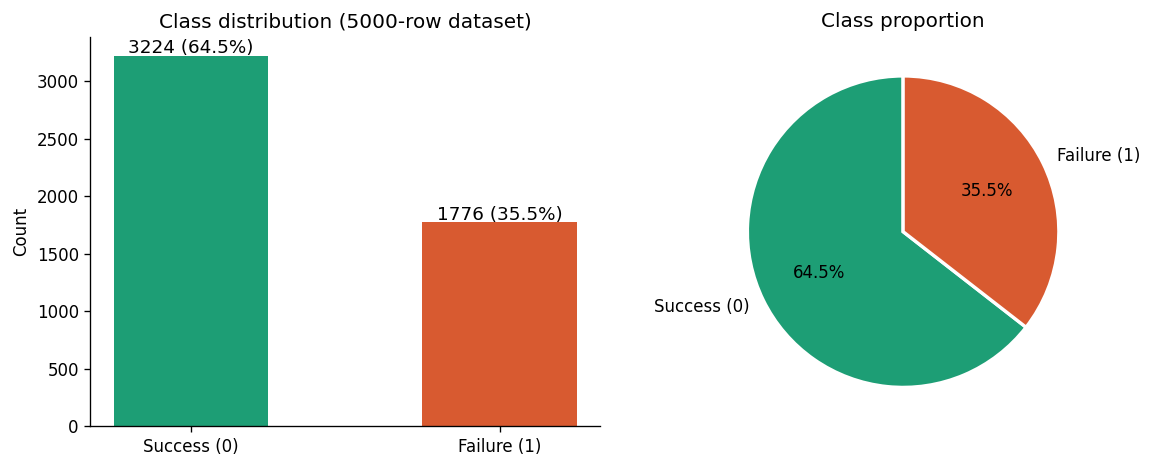

Class imbalance is 64.5% / 35.5%; Owners E and F should use weighted loss.


In [47]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Bar chart
counts = df[TARGET].value_counts()
axes[0].bar(['Success (0)', 'Failure (1)'], counts.values,
            color=['#1D9E75', '#D85A30'], width=0.5)
axes[0].set_title('Class distribution (5000-row dataset)')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 20, f'{v} ({v/len(df):.1%})', ha='center', fontsize=11)

# Pie chart
axes[1].pie(counts.values, labels=['Success (0)', 'Failure (1)'],
            colors=['#1D9E75', '#D85A30'], autopct='%1.1f%%',
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class proportion')

plt.tight_layout()
plt.show()
print('Class imbalance is 64.5% / 35.5%; Owners E and F should use weighted loss.')

## 6. Feature histograms (split by class)

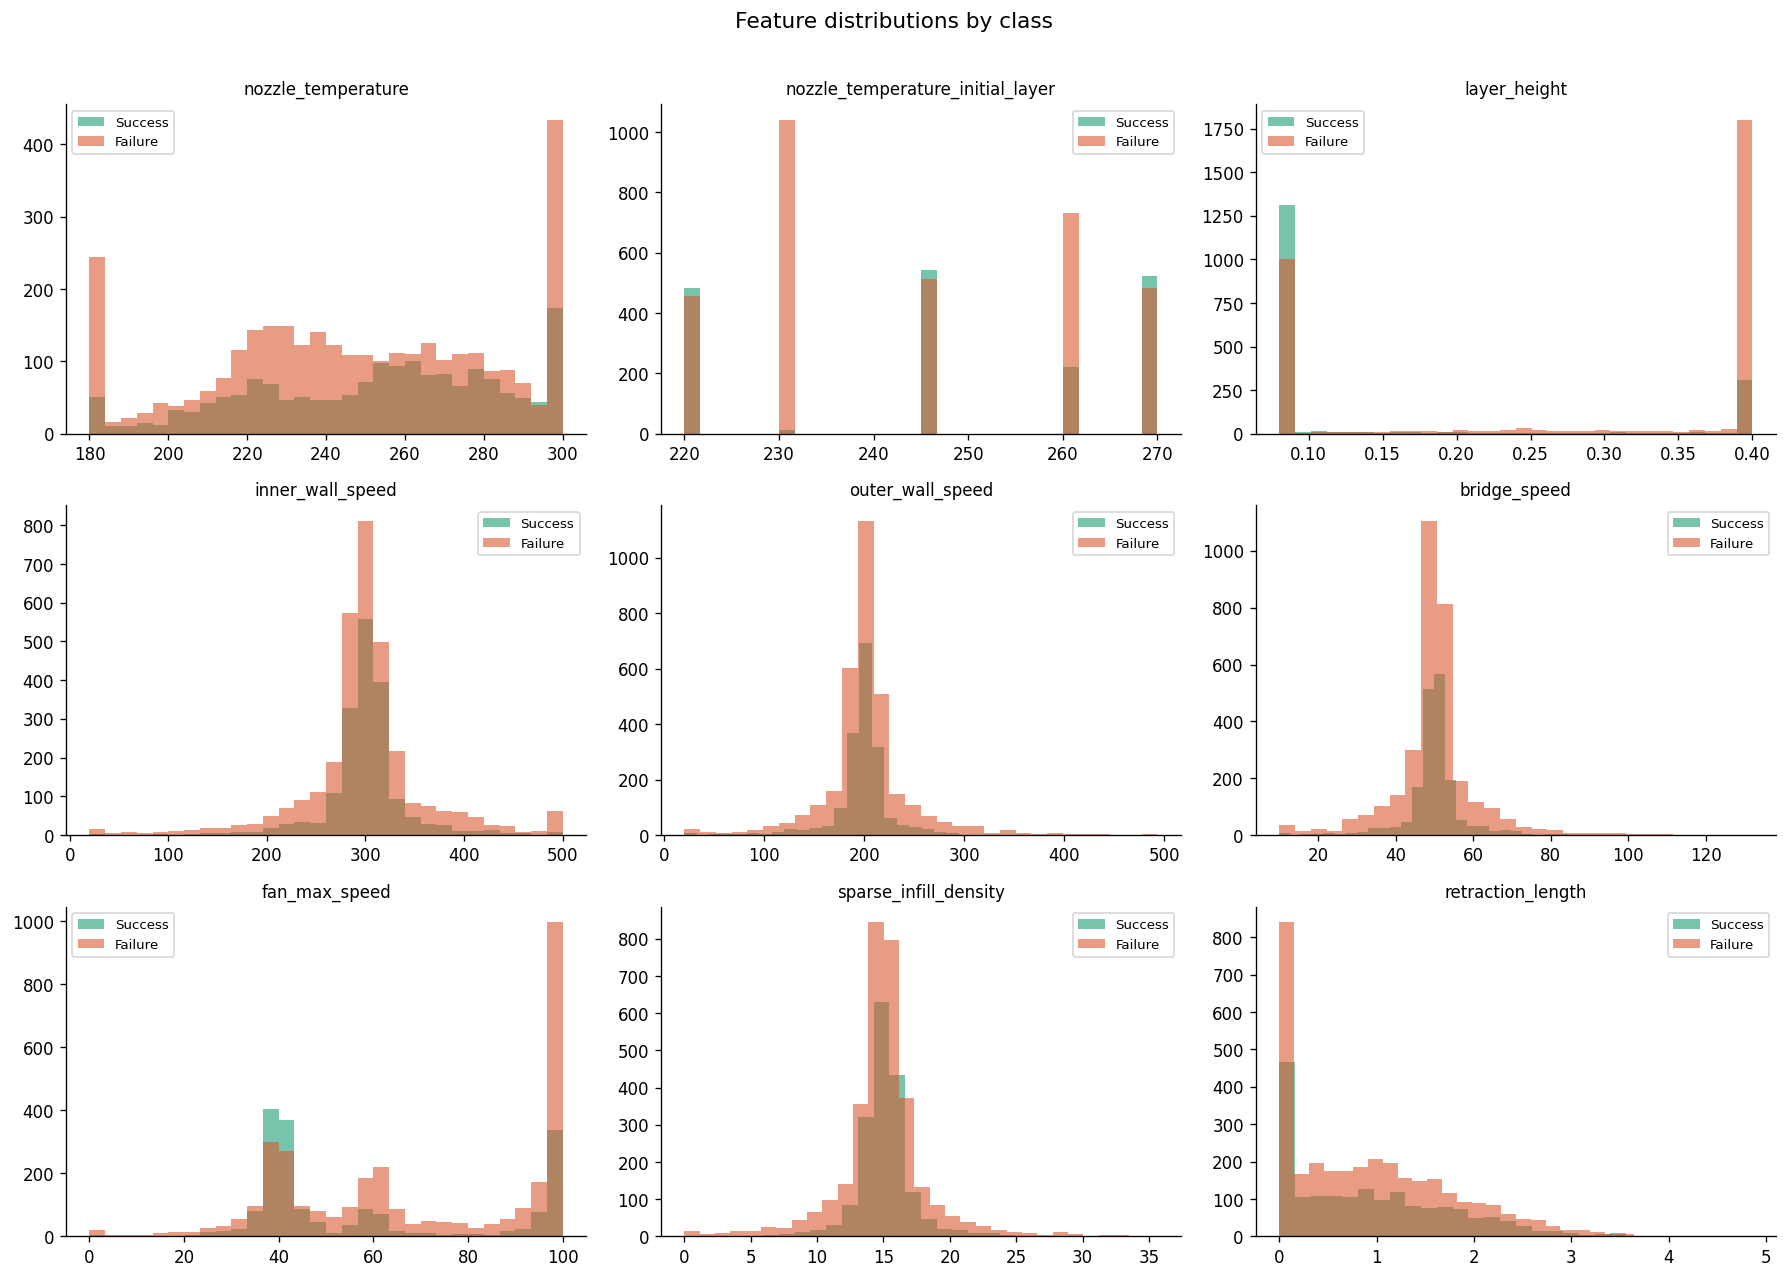

In [48]:
num_features = [c for c in NUMERIC_CANDIDATES if c in df_clean.columns]
n_cols = 3
n_rows = (len(num_features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 3.5))
axes = axes.flatten()

success = df_clean[df_clean[TARGET] == 0]
failure = df_clean[df_clean[TARGET] == 1]

for i, col in enumerate(num_features):
    ax = axes[i]
    ax.hist(success[col].dropna(), bins=30, alpha=0.6, color='#1D9E75', label='Success')
    ax.hist(failure[col].dropna(), bins=30, alpha=0.6, color='#D85A30', label='Failure')
    ax.set_title(col, fontsize=10)
    ax.legend(fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature distributions by class', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 7. Boxplots by class

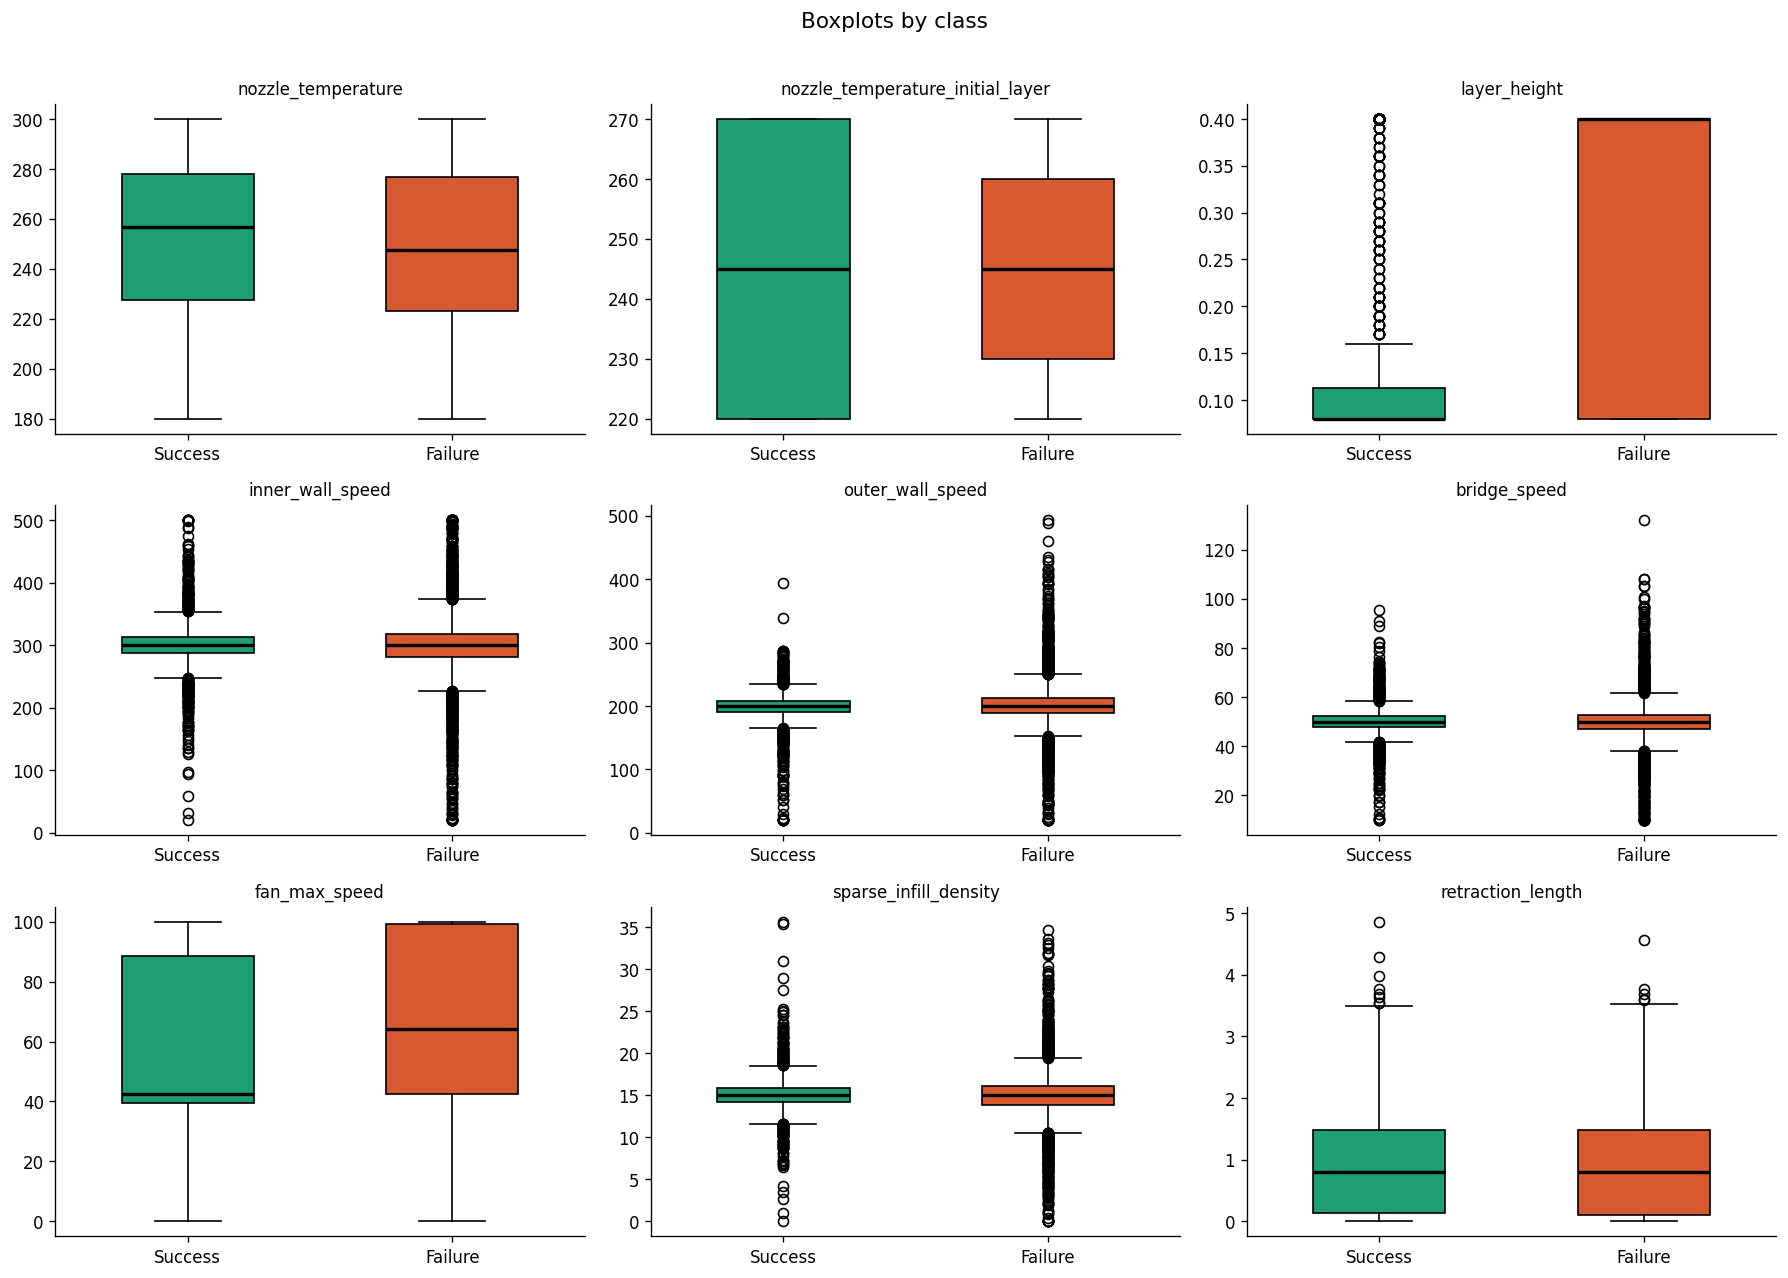

In [49]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 3.5))
axes = axes.flatten()

for i, col in enumerate(num_features):
    ax = axes[i]
    data = [success[col].dropna(), failure[col].dropna()]
    bp = ax.boxplot(data, patch_artist=True, widths=0.5,
                    medianprops={'color': 'black', 'linewidth': 2})
    bp['boxes'][0].set_facecolor('#1D9E75')
    bp['boxes'][1].set_facecolor('#D85A30')
    ax.set_xticklabels(['Success', 'Failure'])
    ax.set_title(col, fontsize=10)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots by class', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 8. Filament type vs failure rate

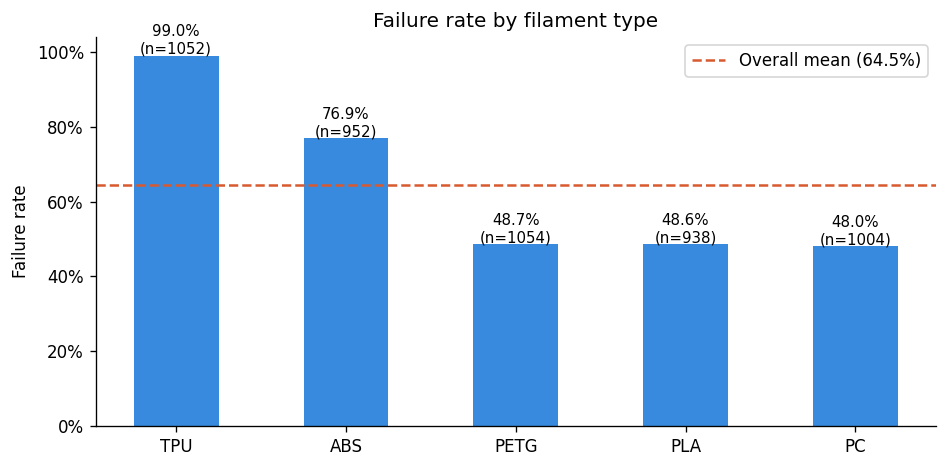

filament_type  failure_rate  count
          TPU      0.989544   1052
          ABS      0.768908    952
         PETG      0.486717   1054
          PLA      0.486141    938
           PC      0.480080   1004


In [50]:
filament_failure = df_clean.groupby('filament_type')[TARGET].agg(['mean','count']).reset_index()
filament_failure.columns = ['filament_type', 'failure_rate', 'count']
filament_failure = filament_failure.sort_values('failure_rate', ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(filament_failure['filament_type'], filament_failure['failure_rate'],
              color='#378ADD', width=0.5)
ax.axhline(df_clean[TARGET].mean(), color='#D85A30', linestyle='--',
           linewidth=1.5, label=f'Overall mean ({df_clean[TARGET].mean():.1%})')
ax.set_ylabel('Failure rate')
ax.set_title('Failure rate by filament type')
ax.legend()
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
for bar, (_, row) in zip(bars, filament_failure.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{row["failure_rate"]:.1%}\n(n={int(row["count"])})',
            ha='center', fontsize=9)
plt.tight_layout()
plt.show()
print(filament_failure.to_string(index=False))

## 9. Correlation heatmap

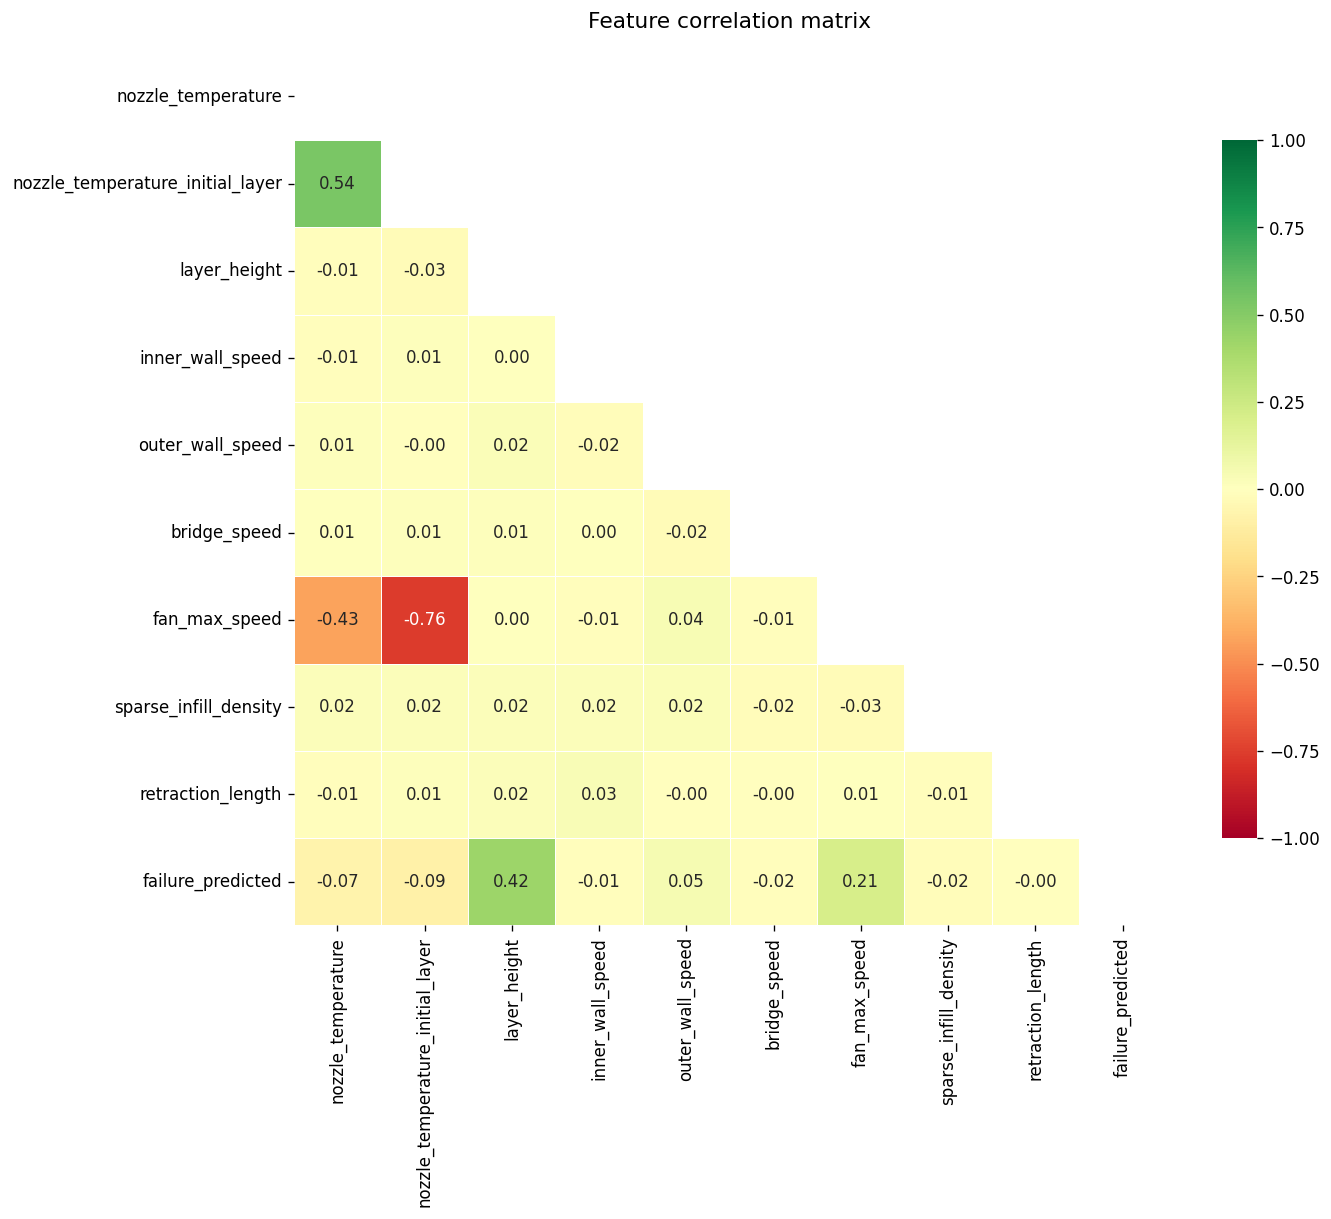


Top feature correlations with failure_predicted:
  layer_height                             0.422  ↑ failure
  fan_max_speed                            0.208  ↑ failure
  nozzle_temperature_initial_layer         0.093  ↓ failure
  nozzle_temperature                       0.072  ↓ failure
  outer_wall_speed                         0.051  ↑ failure
  sparse_infill_density                    0.018  ↓ failure
  bridge_speed                             0.015  ↓ failure
  inner_wall_speed                         0.011  ↓ failure
  retraction_length                        0.000  ↓ failure


In [51]:
corr_cols = [c for c in num_features if c in df_clean.columns] + [TARGET]
corr_df = df_clean[corr_cols].dropna()
corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=-1, vmax=1, center=0, square=True, linewidths=0.5,
            ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Feature correlation matrix', fontsize=13, pad=15)
plt.tight_layout()
plt.show()

# Top correlations with target
target_corr = corr_matrix[TARGET].drop(TARGET).abs().sort_values(ascending=False)
print('\nTop feature correlations with failure_predicted:')
for feat, val in target_corr.head(10).items():
    direction = '↑ failure' if corr_matrix[TARGET][feat] > 0 else '↓ failure'
    print(f'  {feat:<40} {val:.3f}  {direction}')

## 10. Summary & handoff to Owner B

In [52]:
# Build feature_candidates.json for Owner B
feature_candidates = {
    'numeric': NUMERIC_CANDIDATES,
    'categorical': CATEGORICAL_CANDIDATES,
    'target': TARGET,
    'drop_zero_variance': zero_var_cols,
    'imputation_strategy': {
        col: 'median' for col in null_summary.index
        if np.issubdtype(df_clean[col].dtype, np.number)
    },
    'class_balance': {
        '0_success': int((df[TARGET] == 0).sum()),
        '1_failure': int((df[TARGET] == 1).sum()),
        'failure_rate': round(float(df[TARGET].mean()), 4),
    },
    'notes': [
        'Use the 5000-row dataset for training (strongest signal).',
        'Failure class is about 64.5%, so E and F should use weighted loss.',
        'filament_type should be one-hot encoded (5 categories).',
    ]
}

out_path = '../data/raw/feature_candidates.json'
with open(out_path, 'w') as f:
    json.dump(feature_candidates, f, indent=2)

print('Saved feature_candidates.json for Owner B')
print(f'   Numeric features: {len(NUMERIC_CANDIDATES)}')
print(f'   Categorical features: {len(CATEGORICAL_CANDIDATES)}')
print(f'   Zero-variance columns to drop: {len(zero_var_cols)}')
print(f'   Failure rate: {feature_candidates["class_balance"]["failure_rate"]:.1%}')
print('\nHand this file to Owner B before preprocessing starts.')

Saved feature_candidates.json for Owner B
   Numeric features: 15
   Categorical features: 1
   Zero-variance columns to drop: 409
   Failure rate: 64.5%

Hand this file to Owner B before preprocessing starts.
